# 🌿 Biodiversity in National Parks – Exploratory Data Analysis

## 📌 Project Introduction

This project explores biodiversity data from four U.S. national parks to understand species distribution, conservation status, and observation trends across different categories of wildlife and plants. Using Python libraries such as Pandas, Matplotlib, and Seaborn, the analysis investigates how species are observed in different parks, which categories are most protected, and which endangered species are most commonly recorded.

The project combines two datasets:

- species_info.csv → contains species details and conservation status
- observations.csv → contains observation counts across parks

The main objective is to uncover patterns related to biodiversity, endangered species, and protected wildlife within national parks through data visualization and statistical analysis.

### 📚 Importing Libraries and Loading Datasets

In [1]:
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

### 🔍 Explanation

The required Python libraries for data analysis and visualization are imported:

Pandas for data manipulation
NumPy for numerical operations
Matplotlib & Seaborn for visualizations

### 👀 Loading and previewing the Datasets

In [2]:
observations = pd.read_csv('observations.csv')
observations.head()

,scientific_name,park_name,observations
0,Vicia benghalensis,Great Smoky Mountains National Park,68
1,Neovison vison,Great Smoky Mountains National Park,77
2,Prunus subcordata,Yosemite National Park,138
3,Abutilon theophrasti,Bryce National Park,84
4,Githopsis specularioides,Great Smoky Mountains National Park,85


In [3]:
species_info = pd.read_csv('species_info.csv')
species_info.head()

,category,scientific_name,common_names,conservation_status
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,NaN
1,Mammal,Bos bison,"American Bison, Bison",NaN
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",NaN
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",NaN
4,Mammal,Cervus elaphus,Wapiti Or Elk,NaN


### 🔍 Explanation

The two CSV datasets are then loaded into DataFrames for analysis.

The .head() function is used to preview the first five rows of both datasets. This helps in understanding:

- available columns
- structure of the datasets
- data types
- initial data quality

### 📏 Dataset Shape and Basic Information

In [4]:
print("Observations dataset shape:\n", observations.shape)
print("Species info dataset shape:\n", species_info.shape)

Observations dataset shape:
 (23296, 3)
Species info dataset shape:
 (5824, 4)


### 🔍 Explanation

The shape of each dataset is checked to determine:

- total number of rows
- total number of columns

This provides a quick overview of dataset size before starting analysis.

### 🌲 Number of National Parks

In [5]:
print('Number of unique parks:', observations.park_name.nunique())

Number of unique parks: 4


### 🔍 Explanation

- The number of unique national parks in the observations dataset is calculated using .nunique().
- This helps identify how many park locations are included in the biodiversity study.

## 🛡️ Conservation Status Analysis


### 🛡️ Conservation Status by Species Category

In [6]:
category = species_info.groupby(['category']).conservation_status.value_counts()
category

category           conservation_status
Amphibian          Species of Concern      4
                   Threatened              2
                   Endangered              1
Bird               Species of Concern     72
                   Endangered              4
                   In Recovery             3
Fish               Species of Concern      4
                   Threatened              4
                   Endangered              3
Mammal             Species of Concern     28
                   Endangered              7
                   Threatened              2
                   In Recovery             1
Nonvascular Plant  Species of Concern      5
Reptile            Species of Concern      5
Vascular Plant     Species of Concern     43
                   Threatened              2
                   Endangered              1
Name: count, dtype: int64

### 🔍 Explanation

Species are grouped according to their category and conservation status to analyze:

- endangered species
- threatened species
- species of concern
- species in recovery

This helps identify which categories have the highest conservation needs.

### 🔗 Merging the Datasets

In [7]:
merged = species_info.merge(observations, on = 'scientific_name', how = 'outer')
merged.head()

,category,scientific_name,common_names,conservation_status,park_name,observations
0,Vascular Plant,Abies bifolia,Rocky Mountain Alpine Fir,NaN,Bryce National Park,109
1,Vascular Plant,Abies bifolia,Rocky Mountain Alpine Fir,NaN,Yellowstone National Park,215
2,Vascular Plant,Abies bifolia,Rocky Mountain Alpine Fir,NaN,Great Smoky Mountains National Park,72
3,Vascular Plant,Abies bifolia,Rocky Mountain Alpine Fir,NaN,Yosemite National Park,136
4,Vascular Plant,Abies concolor,"Balsam Fir, Colorado Fir, Concolor Fir, Silver...",NaN,Great Smoky Mountains National Park,101


### 🔍 Explanation

- Both datasets are merged using the scientific_name column.
- This combined dataset allows species information and park observations to be analyzed together.

### 🌳 Total Observations by National Park

In [8]:
observations_parks = merged.groupby(['park_name']).observations.sum()
observations_parks

park_name
Bryce National Park                     633291
Great Smoky Mountains National Park     474863
Yellowstone National Park              1587641
Yosemite National Park                  949452
Name: observations, dtype: int64

### Observation counts are grouped by park name to determine:

which parks have the highest biodiversity observations
overall observation activity in each park

### 📈 Visualization – Observations by Park

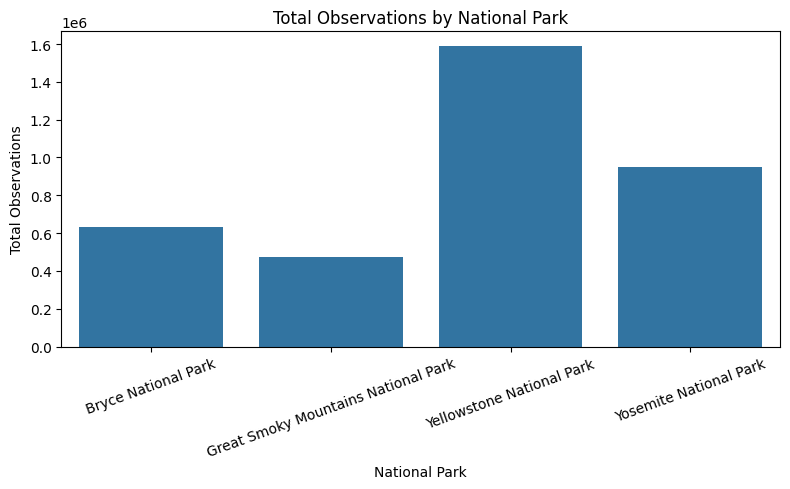

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=observations_parks.index,
    y=observations_parks.values,
    errorbar=None
)

plt.title('Total Observations by National Park')
plt.xlabel('National Park')
plt.ylabel('Total Observations')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 🔍 Explanation

- A bar chart is created to visually compare total species observations across all national parks.
- The graph clearly shows that Yellowstone National Park recorded the highest number of observations.

### 🌱 Total Observations by Species Category

In [10]:
observations_per_category = merged.groupby(['category']).observations.sum()
observations_per_category

category
Amphibian              45068
Bird                  332371
Fish                   72901
Mammal                163120
Nonvascular Plant     190653
Reptile                45822
Vascular Plant       2795312
Name: observations, dtype: int64

### 📌 Insights
- Vascular Plants dominate total observations by a very large margin.
- Birds and Mammals are also highly observed categories.
- Amphibians and Reptiles have relatively lower observation counts.

### 🌍 Species Category Observations Across Parks

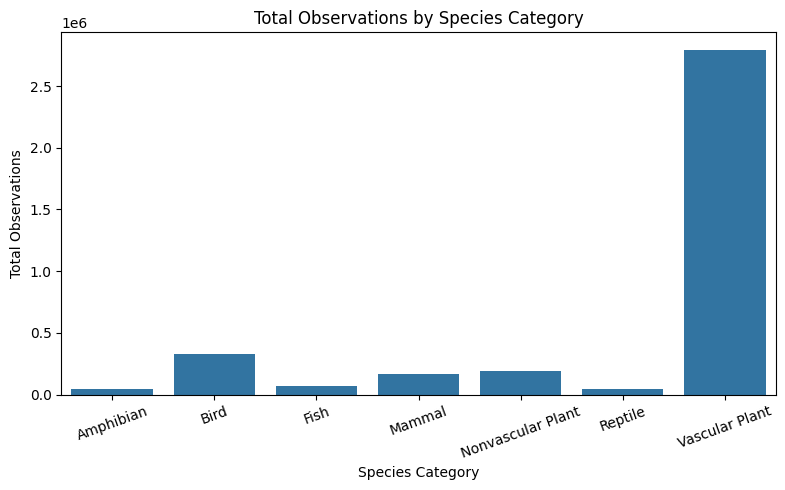

In [11]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=observations_per_category.index,
    y=observations_per_category.values,
    errorbar=None
)

plt.title('Total Observations by Species Category')
plt.xlabel('Species Category')
plt.ylabel('Total Observations')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 📌 Insights
- Vascular Plants are the most observed category in every park.
- Amphibians and Reptiles remain the least observed groups.

### 📉 Maximum and Minimum Observation Categories per Park

In [12]:
observations_per_category_parks = merged.groupby(['park_name','category']).agg({'observations':'sum'}).reset_index()
observations_per_category_parks

,park_name,category,observations
0,Bryce National Park,Amphibian,7542
1,Bryce National Park,Bird,58590
2,Bryce National Park,Fish,12823
3,Bryce National Park,Mammal,28830
4,Bryce National Park,Nonvascular Plant,32992
5,Bryce National Park,Reptile,8141
6,Bryce National Park,Vascular Plant,484373
7,Great Smoky Mountains National Park,Amphibian,5876
8,Great Smoky Mountains National Park,Bird,42869
9,Great Smoky Mountains National Park,Fish,9482


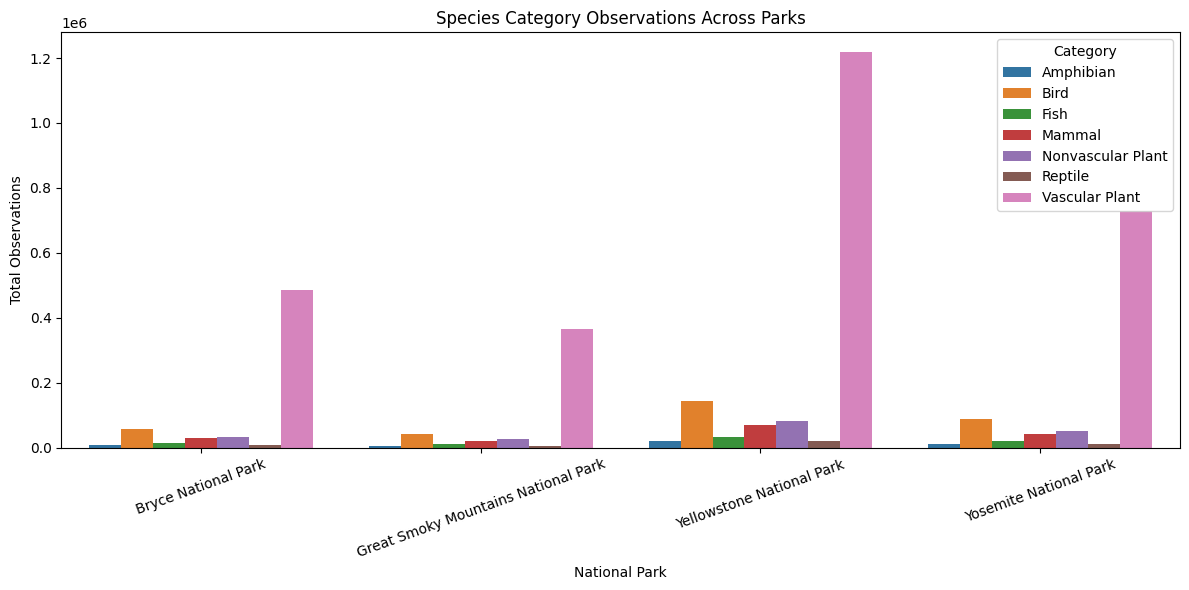

In [13]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=observations_per_category_parks,
    x='park_name',
    y='observations',
    hue='category',
    estimator=sum,
    errorbar=None
)

plt.title('Species Category Observations Across Parks')
plt.xlabel('National Park')
plt.ylabel('Total Observations')
plt.xticks(rotation=20)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

In [14]:
max_category = observations_per_category_parks.loc[
    observations_per_category_parks.groupby('park_name')['observations'].idxmax()
]
max_category

,park_name,category,observations
6,Bryce National Park,Vascular Plant,484373
13,Great Smoky Mountains National Park,Vascular Plant,364882
20,Yellowstone National Park,Vascular Plant,1218162
27,Yosemite National Park,Vascular Plant,727895


In [15]:
min_category = observations_per_category_parks.loc[
    observations_per_category_parks.groupby('park_name')['observations'].idxmin()
]
min_category

,park_name,category,observations
0,Bryce National Park,Amphibian,7542
12,Great Smoky Mountains National Park,Reptile,5841
14,Yellowstone National Park,Amphibian,19937
21,Yosemite National Park,Amphibian,11713


### 📌 Insights
- Vascular Plants are the highest observed category in all parks.
- Amphibians or Reptiles are generally the least observed categories.
- This shows large biodiversity differences between plant and animal groups.

### 🚨 Conservation Status Observations

In [16]:
observations_parks_consv_status = merged.groupby(['park_name','category','conservation_status']).agg({'observations':'sum'}).reset_index()
observations_parks_consv_status

,park_name,category,conservation_status,observations
0,Bryce National Park,Amphibian,Endangered,31
1,Bryce National Park,Amphibian,Species of Concern,387
2,Bryce National Park,Amphibian,Threatened,80
3,Bryce National Park,Bird,Endangered,98
4,Bryce National Park,Bird,In Recovery,258
...,...,...,...,...
67,Yosemite National Park,Nonvascular Plant,Species of Concern,677
68,Yosemite National Park,Reptile,Species of Concern,684
69,Yosemite National Park,Vascular Plant,Endangered,47
70,Yosemite National Park,Vascular Plant,Species of Concern,5794


### 📌 Insights
- Protected species observations vary by category and park.
- Mammals and Birds contribute strongly to endangered observations.
- Conservation tracking is important for biodiversity monitoring.

### 🐾 Endangered Species Analysis

In [17]:
endangered_category = observations_parks_consv_status[
    observations_parks_consv_status['conservation_status'] == 'Endangered'
].reset_index()
print(endangered_category.head())
    

   index            park_name        category conservation_status  \
0      0  Bryce National Park       Amphibian          Endangered   
1      3  Bryce National Park            Bird          Endangered   
2      6  Bryce National Park            Fish          Endangered   
3      9  Bryce National Park          Mammal          Endangered   
4     15  Bryce National Park  Vascular Plant          Endangered   

   observations  
0            31  
1            98  
2            70  
3           395  
4            25  


In [18]:
endangered_species = merged[
    merged['conservation_status'] == 'Endangered'
].reset_index()
print(endangered_species)
    

    index   category      scientific_name  \
0    3624     Mammal          Canis lupus   
1    3625     Mammal          Canis lupus   
2    3626     Mammal          Canis lupus   
3    3627     Mammal          Canis lupus   
4    3628     Mammal          Canis lupus   
..    ...        ...                  ...   
75  19659  Amphibian         Rana sierrae   
76  24760       Bird  Vermivora bachmanii   
77  24761       Bird  Vermivora bachmanii   
78  24762       Bird  Vermivora bachmanii   
79  24763       Bird  Vermivora bachmanii   

                                 common_names conservation_status  \
0                                   Gray Wolf          Endangered   
1                                   Gray Wolf          Endangered   
2                                   Gray Wolf          Endangered   
3                                   Gray Wolf          Endangered   
4                                   Gray Wolf          Endangered   
..                                        ...

### 📌 Insights
- Multiple endangered species appear across different parks.
- Mammals have some of the highest endangered observation counts.
- Species protection efforts remain critical.

### 📊 Endangered Species Observations by Category

In [19]:
endangered_species_count = endangered_species.groupby(['category']).observations.sum()
endangered_species_count

category
Amphibian          144
Bird               574
Fish               455
Mammal            2178
Vascular Plant     162
Name: observations, dtype: int64

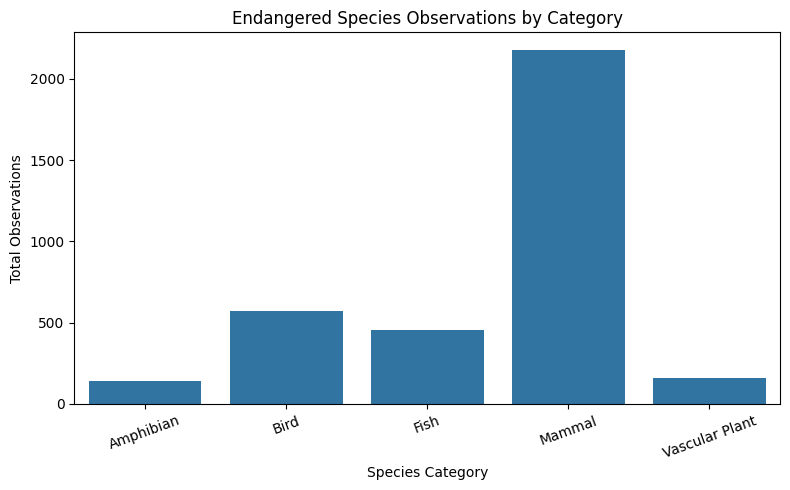

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=endangered_species_count.index,
    y=endangered_species_count.values,
    errorbar=None
)

plt.title('Endangered Species Observations by Category')
plt.xlabel('Species Category')
plt.ylabel('Total Observations')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 📌 Insights
- Mammals recorded the highest endangered species observations.
- Birds and Fish also contribute significant endangered counts.
- Amphibians have the lowest endangered observations.

### 🐾 Maximum Endangered Species Observations Across Parks

In [21]:
max_obs_endangered_species = endangered_species.loc[
    endangered_species.groupby(['category','park_name'])['observations'].idxmax()
].reset_index()
max_obs_endangered_species


,level_0,index,category,scientific_name,common_names,conservation_status,park_name,observations
0,74,19658,Amphibian,Rana sierrae,Sierra Nevada Yellow-Legged Frog,Endangered,Bryce National Park,31
1,75,19659,Amphibian,Rana sierrae,Sierra Nevada Yellow-Legged Frog,Endangered,Great Smoky Mountains National Park,11
2,73,19657,Amphibian,Rana sierrae,Sierra Nevada Yellow-Legged Frog,Endangered,Yellowstone National Park,60
3,72,19656,Amphibian,Rana sierrae,Sierra Nevada Yellow-Legged Frog,Endangered,Yosemite National Park,42
4,48,10656,Bird,Gymnogyps californianus,California Condor,Endangered,Bryce National Park,30
5,79,24763,Bird,Vermivora bachmanii,"Bachman's Warbler, Bachman's Wood Warbler",Endangered,Great Smoky Mountains National Park,18
6,51,10659,Bird,Gymnogyps californianus,California Condor,Endangered,Yellowstone National Park,64
7,49,10657,Bird,Gymnogyps californianus,California Condor,Endangered,Yosemite National Park,47
8,34,9322,Fish,Etheostoma percnurum,Duskytail Darter,Endangered,Bryce National Park,25
9,33,9321,Fish,Etheostoma percnurum,Duskytail Darter,Endangered,Great Smoky Mountains National Park,31


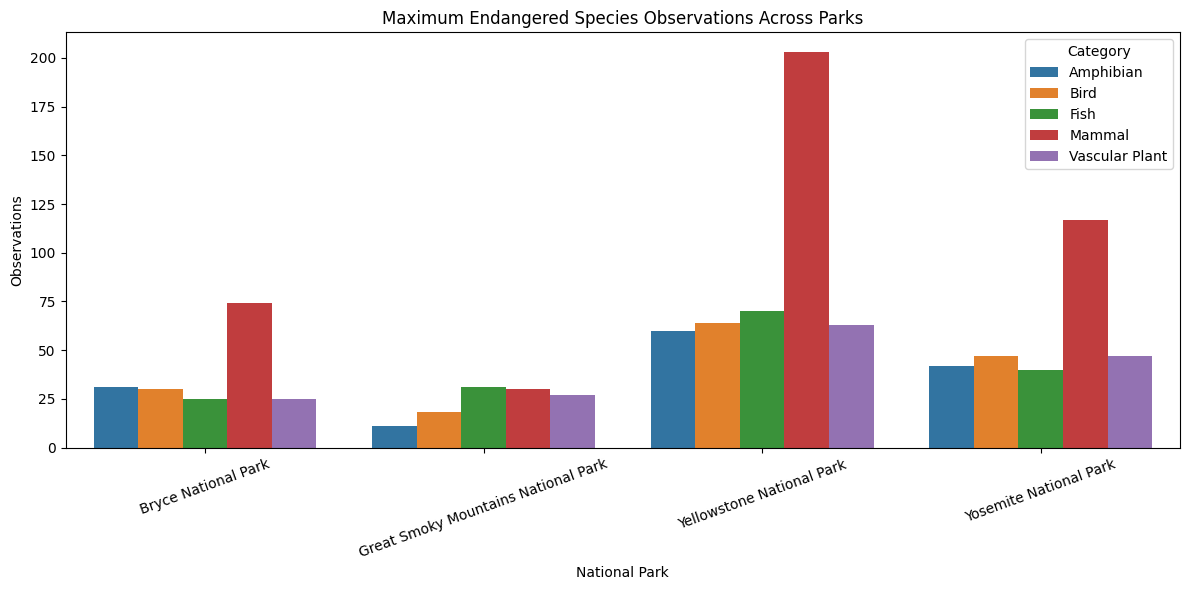

In [22]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=max_obs_endangered_species,
    x='park_name',
    y='observations',
    hue='category',
    estimator=sum,
    errorbar=None
)

plt.title('Maximum Endangered Species Observations Across Parks')
plt.xlabel('National Park')
plt.ylabel('Observations')
plt.xticks(rotation=20)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

### 🔍 Insights
- Gray Wolves recorded the highest endangered mammal observations.
- Yellowstone National Park showed the highest endangered species observations overall.
- Birds, Fish, and Mammals displayed noticeable variation across parks.
- Mammals consistently dominated endangered species observations.


### 📉 Minimum Endangered Species Observations Across Parks

In [23]:
min_obs_endangered_species = endangered_species.loc[
    endangered_species.groupby(['category','park_name'])['observations'].idxmin()
].reset_index()
min_obs_endangered_species


,level_0,index,category,scientific_name,common_names,conservation_status,park_name,observations
0,74,19658,Amphibian,Rana sierrae,Sierra Nevada Yellow-Legged Frog,Endangered,Bryce National Park,31
1,75,19659,Amphibian,Rana sierrae,Sierra Nevada Yellow-Legged Frog,Endangered,Great Smoky Mountains National Park,11
2,73,19657,Amphibian,Rana sierrae,Sierra Nevada Yellow-Legged Frog,Endangered,Yellowstone National Park,60
3,72,19656,Amphibian,Rana sierrae,Sierra Nevada Yellow-Legged Frog,Endangered,Yosemite National Park,42
4,76,24760,Bird,Vermivora bachmanii,"Bachman's Warbler, Bachman's Wood Warbler",Endangered,Bryce National Park,20
5,44,10636,Bird,Grus americana,Whooping Crane,Endangered,Great Smoky Mountains National Park,13
6,45,10637,Bird,Grus americana,Whooping Crane,Endangered,Yellowstone National Park,57
7,47,10639,Bird,Grus americana,Whooping Crane,Endangered,Yosemite National Park,37
8,62,15642,Fish,Noturus baileyi,Smoky Madtom,Endangered,Bryce National Park,22
9,30,5442,Fish,Chasmistes liorus,June Sucker,Endangered,Great Smoky Mountains National Park,23


### 🔍 Insights
- Some endangered species were observed only a few times across parks.
- Great Smoky Mountains had several of the lowest endangered species observations.
- Rare observation counts may indicate lower population levels.
- Species such as the Red Wolf and Whooping Crane require continued conservation attention.

### 🐺 Most and Least Observed Endangered Species

In [24]:
max_endangered_species_per_category = endangered_species.loc[
    endangered_species.groupby('category')['observations'].idxmax()
].reset_index()
max_endangered_species_per_category


,level_0,index,category,scientific_name,common_names,conservation_status,park_name,observations
0,73,19657,Amphibian,Rana sierrae,Sierra Nevada Yellow-Legged Frog,Endangered,Yellowstone National Park,60
1,51,10659,Bird,Gymnogyps californianus,California Condor,Endangered,Yellowstone National Park,64
2,32,9320,Fish,Etheostoma percnurum,Duskytail Darter,Endangered,Yellowstone National Park,70
3,7,3631,Mammal,Canis lupus,Gray Wolf,Endangered,Yellowstone National Park,203
4,37,10389,Vascular Plant,Geum radiatum,"Mountain Avens, Spreading Avens",Endangered,Yellowstone National Park,63


In [25]:
min_endangered_species_per_category = endangered_species.loc[
    endangered_species.groupby('category')['observations'].idxmin()
].reset_index()
min_endangered_species_per_category


,level_0,index,category,scientific_name,common_names,conservation_status,park_name,observations
0,75,19659,Amphibian,Rana sierrae,Sierra Nevada Yellow-Legged Frog,Endangered,Great Smoky Mountains National Park,11
1,44,10636,Bird,Grus americana,Whooping Crane,Endangered,Great Smoky Mountains National Park,13
2,62,15642,Fish,Noturus baileyi,Smoky Madtom,Endangered,Bryce National Park,22
3,26,3662,Mammal,Canis rufus,Red Wolf,Endangered,Great Smoky Mountains National Park,13
4,39,10391,Vascular Plant,Geum radiatum,"Mountain Avens, Spreading Avens",Endangered,Bryce National Park,25


### 📌 Insights
- Gray Wolf had the highest endangered observations among mammals.
- Yellowstone frequently recorded the highest endangered counts.
- Some endangered species remain rarely observed.

### 🛡️ Protected Species Percentage by Category

In [26]:
category_count = species_info['category'].value_counts()
category_count

category
Vascular Plant       4470
Bird                  521
Nonvascular Plant     333
Mammal                214
Fish                  127
Amphibian              80
Reptile                79
Name: count, dtype: int64

In [27]:
species_info.fillna('No Intervention', inplace=True)
species_info.groupby("conservation_status").size()

conservation_status
Endangered              16
In Recovery              4
No Intervention       5633
Species of Concern     161
Threatened              10
dtype: int64

In [28]:
species_info['is_protected'] = species_info.conservation_status != 'No Intervention'

In [29]:
category_counts = species_info.groupby(['category','is_protected']).scientific_name.nunique().reset_index().pivot(columns='is_protected',index='category',values='scientific_name').reset_index()
category_counts.columns=['category','not_protected','protected']
category_counts

,category,not_protected,protected
0,Amphibian,72,7
1,Bird,413,75
2,Fish,115,11
3,Mammal,146,30
4,Nonvascular Plant,328,5
5,Reptile,73,5
6,Vascular Plant,4216,46


In [30]:
category_counts['percent_protected'] = (
    category_counts['protected'] /
    (category_counts['protected'] + category_counts['not_protected'])
) * 100

category_counts

,category,not_protected,protected,percent_protected
0,Amphibian,72,7,8.860759
1,Bird,413,75,15.368852
2,Fish,115,11,8.730159
3,Mammal,146,30,17.045455
4,Nonvascular Plant,328,5,1.501502
5,Reptile,73,5,6.410256
6,Vascular Plant,4216,46,1.079305


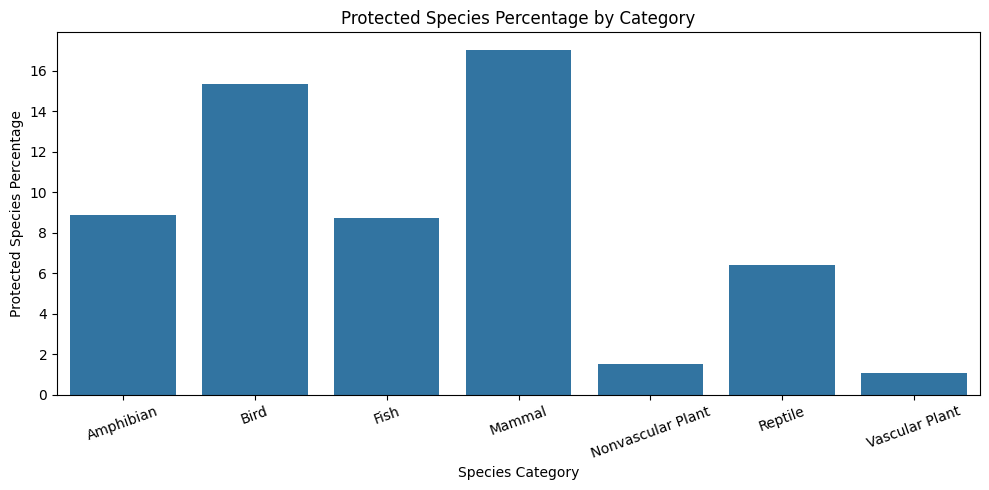

In [31]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=category_counts,
    x='category',
    y='percent_protected',
    errorbar=None
)

plt.title('Protected Species Percentage by Category')
plt.xlabel('Species Category')
plt.ylabel('Protected Species Percentage')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 📌 Insights
- Mammals have the highest percentage of protected species.
- Birds also contain many protected species.
- Plant categories have relatively lower protection percentages.

### 📈 Observations by Conservation Status

In [32]:
status_obs = merged.groupby('conservation_status')['observations'].sum().reset_index()

status_obs

,conservation_status,observations
0,Endangered,3513
1,In Recovery,2107
2,Species of Concern,93962
3,Threatened,3339


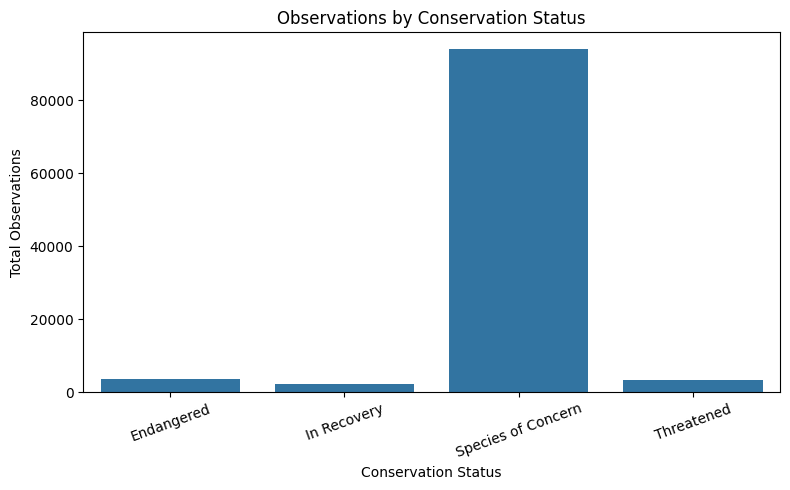

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=status_obs,
    x='conservation_status',
    y='observations',
    errorbar=None
)

plt.title('Observations by Conservation Status')
plt.xlabel('Conservation Status')
plt.ylabel('Total Observations')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 📌 Insights
- Species of Concern recorded the highest observations.
- Threatened and Endangered categories had lower totals.
- Conservation status significantly affects species distribution.

### 🔥 Heatmap of Species Observations

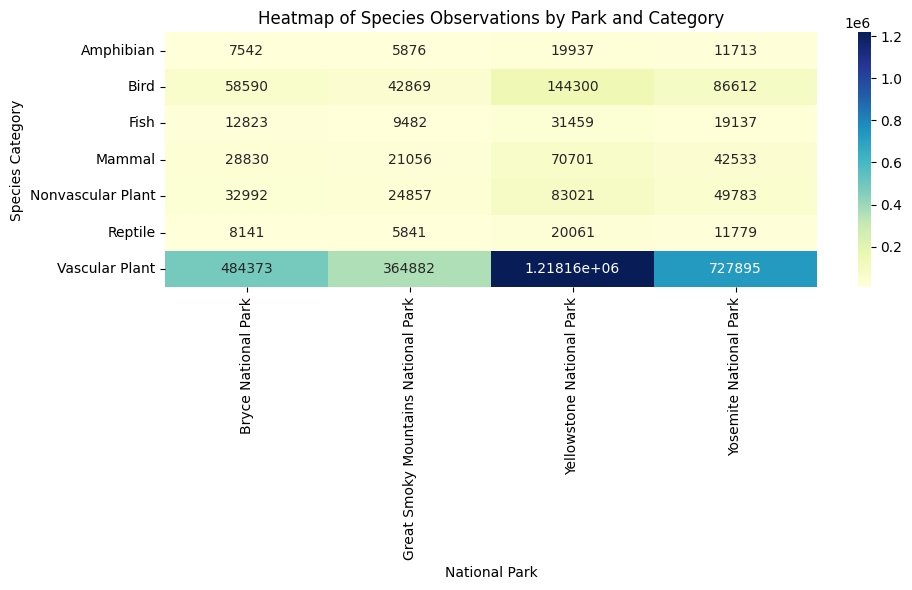

In [34]:
heatmap_data = merged.pivot_table(
    values='observations',
    index='category',
    columns='park_name',
    aggfunc='sum'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='g',
    cmap='YlGnBu'
)

plt.title('Heatmap of Species Observations by Park and Category')
plt.xlabel('National Park')
plt.ylabel('Species Category')
plt.tight_layout()
plt.show()

### 📌 Insights
- Yellowstone shows the highest observation density overall.
- Vascular Plants dominate the heatmap values.
- Amphibians and Reptiles display lower intensity across parks.

In [35]:
top_endangered = endangered_species.loc[
    endangered_species.groupby('park_name')['observations'].idxmax()
]

top_endangered

,index,category,scientific_name,common_names,conservation_status,park_name,observations
3,3627,Mammal,Canis lupus,Gray Wolf,Endangered,Bryce National Park,74
33,9321,Fish,Etheostoma percnurum,Duskytail Darter,Endangered,Great Smoky Mountains National Park,31
7,3631,Mammal,Canis lupus,Gray Wolf,Endangered,Yellowstone National Park,203
9,3633,Mammal,Canis lupus,Gray Wolf,Endangered,Yosemite National Park,117


### 🐿️ Squirrel Species Analysis
The project also investigates squirrel species separately to study protected and non-protected squirrel observations.

In [36]:
species_info['is_squirrel'] = (
    (species_info['category'] == 'Mammal') &
    (species_info['common_names'].str.contains(r"\bSquirrel\b", regex=True))
)

species_info.head(10)

,category,scientific_name,common_names,conservation_status,is_protected,is_squirrel
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,No Intervention,False,False
1,Mammal,Bos bison,"American Bison, Bison",No Intervention,False,False
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",No Intervention,False,False
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",No Intervention,False,False
4,Mammal,Cervus elaphus,Wapiti Or Elk,No Intervention,False,False
5,Mammal,Odocoileus virginianus,White-Tailed Deer,No Intervention,False,False
6,Mammal,Sus scrofa,"Feral Hog, Wild Pig",No Intervention,False,False
7,Mammal,Canis latrans,Coyote,Species of Concern,True,False
8,Mammal,Canis lupus,Gray Wolf,Endangered,True,False
9,Mammal,Canis rufus,Red Wolf,Endangered,True,False


In [37]:
species_info[species_info.is_squirrel]

,category,scientific_name,common_names,conservation_status,is_protected,is_squirrel
72,Mammal,Glaucomys sabrinus coloratus,"Carolina Northern Flying Squirrel, Northern Fl...",Endangered,True,True
73,Mammal,Glaucomys volans,Southern Flying Squirrel,No Intervention,False,True
75,Mammal,Sciurus carolinensis,"Eastern Gray Squirrel, Gray Squirrel",No Intervention,False,True
76,Mammal,Sciurus niger,"Eastern Fox Squirrel, Fox Squirrel",No Intervention,False,True
78,Mammal,Tamiasciurus hudsonicus,Red Squirrel,No Intervention,False,True
3061,Mammal,Glaucomys sabrinus,Northern Flying Squirrel,No Intervention,False,True
3066,Mammal,Spermophilus armatus,Uinta Ground Squirrel,No Intervention,False,True
3067,Mammal,Spermophilus lateralis,Golden-Mantled Ground Squirrel,No Intervention,False,True
4488,Mammal,Callospermophilus lateralis,Golden-Mantled Ground Squirrel,No Intervention,False,True
4489,Mammal,Otospermophilus beecheyi,California Ground Squirrel,No Intervention,False,True


In [38]:
squirrel_observations = observations.merge(species_info[species_info.is_squirrel])
squirrel_observations.head()

,scientific_name,park_name,observations,category,common_names,conservation_status,is_protected,is_squirrel
0,Urocitellus beldingi,Yosemite National Park,157,Mammal,Belding's Ground Squirrel,No Intervention,False,True
1,Callospermophilus lateralis,Great Smoky Mountains National Park,84,Mammal,Golden-Mantled Ground Squirrel,No Intervention,False,True
2,Spermophilus armatus,Yosemite National Park,123,Mammal,Uinta Ground Squirrel,No Intervention,False,True
3,Glaucomys sabrinus,Yellowstone National Park,274,Mammal,Northern Flying Squirrel,No Intervention,False,True
4,Urocitellus beldingi,Bryce National Park,131,Mammal,Belding's Ground Squirrel,No Intervention,False,True


### 📌 Insights
- Several squirrel species were identified across parks.
- Most squirrel species are not protected.
- Some endangered squirrel species still exist.

### 🌲 Protected vs Non-Protected Squirrel Observations

In [39]:
squirrel_observations.groupby('park_name').observations.sum().reset_index()

,park_name,observations
0,Bryce National Park,1064
1,Great Smoky Mountains National Park,864
2,Yellowstone National Park,2857
3,Yosemite National Park,1524


In [40]:
sqrl_obs_by_park = squirrel_observations.groupby(['park_name', 'is_protected']).observations.sum().reset_index()
sqrl_obs_by_park

,park_name,is_protected,observations
0,Bryce National Park,False,1035
1,Bryce National Park,True,29
2,Great Smoky Mountains National Park,False,843
3,Great Smoky Mountains National Park,True,21
4,Yellowstone National Park,False,2790
5,Yellowstone National Park,True,67
6,Yosemite National Park,False,1488
7,Yosemite National Park,True,36


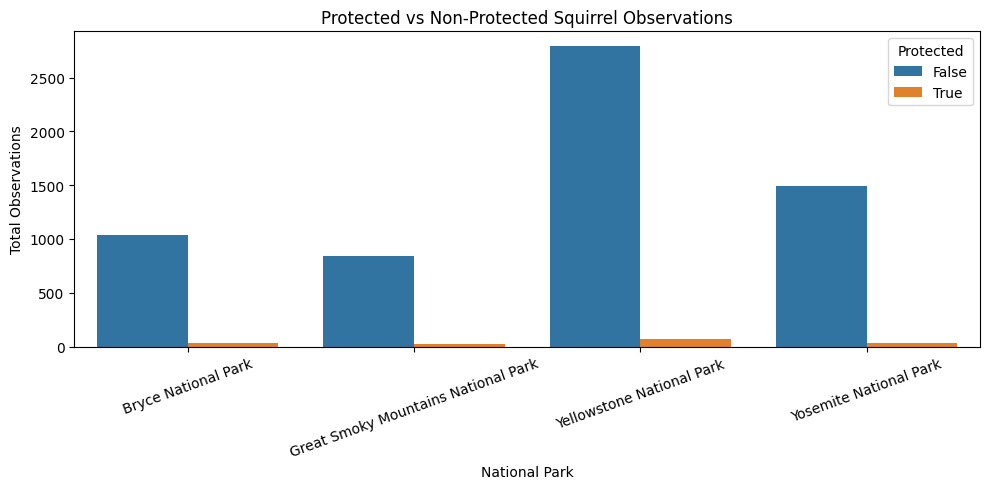

In [41]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=sqrl_obs_by_park,
    x='park_name',
    y='observations',
    hue='is_protected'
)

plt.title('Protected vs Non-Protected Squirrel Observations')
plt.xlabel('National Park')
plt.ylabel('Total Observations')
plt.xticks(rotation=20)
plt.legend(title='Protected')
plt.tight_layout()
plt.show()

### 📌 Insights
- Non-protected squirrels dominate observations in all parks.
- Yellowstone recorded the highest squirrel observations overall.
- Protected squirrel species remain relatively rare.

### 📉 Least Observed Species

In [42]:
least_observed_species = merged.groupby('common_names')['observations']\
.sum()\
.sort_values()\
.head(10)\
.reset_index()

least_observed_species

,common_names,observations
0,Whooping Crane,131
1,Red Wolf,137
2,"Bachman's Warbler, Bachman's Wood Warbler",141
3,Smoky Madtom,143
4,Sierra Nevada Yellow-Legged Frog,144
5,"Indiana Bat, Indiana Or Social Myotis",145
6,June Sucker,146
7,Red-Cockaded Woodpecker,146
8,Sierra Nevada Bighorn Sheep,153
9,"Carolina Northern Flying Squirrel, Northern Fl...",153


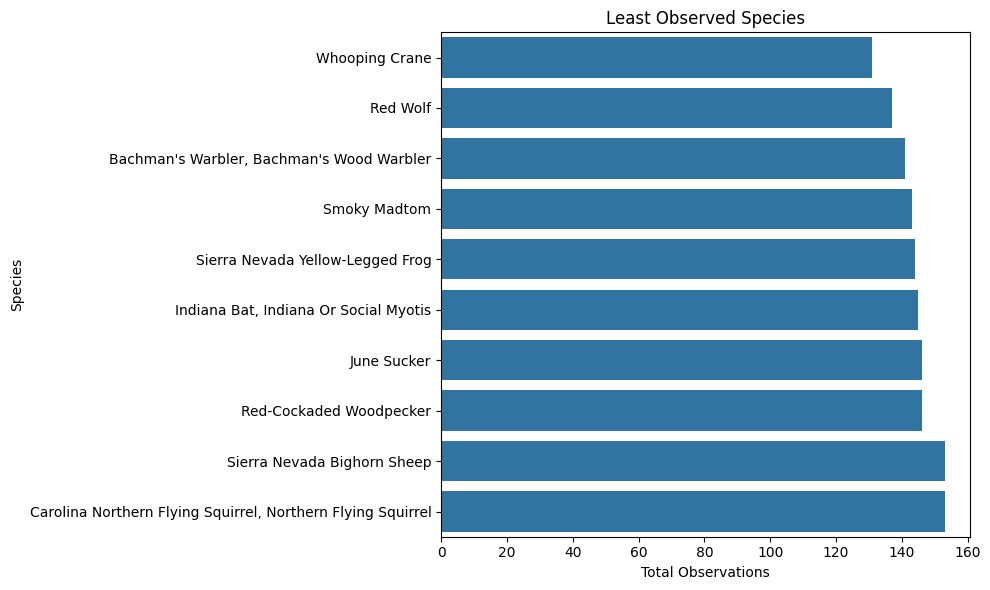

In [43]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=least_observed_species,
    x='observations',
    y='common_names',
    errorbar=None
)

plt.title('Least Observed Species')
plt.xlabel('Total Observations')
plt.ylabel('Species')
plt.tight_layout()
plt.show()

### 📌 Insights
Several endangered species appear among the least observed species.
Rare wildlife species require greater conservation focus.
Low observation counts may indicate population decline.

# ✅ Conclusion
This biodiversity analysis provided valuable insights into wildlife observations and conservation trends across four national parks.

Key findings from the analysis include:

- Yellowstone National Park recorded the highest number of observations.
- Vascular Plants dominate species observations across all parks.
- Mammals and Birds contain the highest number of protected species.
- Endangered species such as the Gray Wolf and California Condor remain important conservation priorities.
- Protected squirrel species are observed far less frequently than non-protected species.

Overall, the project demonstrates how data analysis and visualization can help understand biodiversity patterns and support wildlife conservation efforts.